# ANA 680 — Assignment 3: Three-Layer ANN for Bank Churn
**Name:** David Hall

**Date:** 08/10/2025

**Dataset:** `Churn_Modelling.csv`  
**Goal:** Predict whether a bank customer will churn (`Exited` = 1) or not (`Exited` = 0).

### Requirements:
- **Split:** 80% train / 20% test (stratified by target)
- **Preprocessing:** Encode categorical features, scale numerical features
- **Model:** 3 Dense layers (ReLU / ReLU / Sigmoid)
- **Compile:** Adam optimizer, Binary Crossentropy loss
- **Output:** Accuracy & Confusion Matrix (test set)
- **Extra:** Identify significant features (auxiliary, for discussion)


In [1]:
# Install dependencies if needed
# !pip install numpy pandas scikit-learn tensorflow matplotlib


## 1. Imports & Reproducibility
We import the required libraries and set a fixed random seed for reproducibility.


In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Auxiliary for feature significance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ANN (Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Plotting
import matplotlib.pyplot as plt

# Seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 2. Load the Dataset
We will attempt to load `Churn_Modelling.csv` from the current working directory or the provided `/mnt/data` path.


In [3]:
candidates = ["Churn_Modelling.csv", "/mnt/data/Churn_Modelling.csv"]
csv_path = next((p for p in candidates if os.path.exists(p)), None)
if not csv_path:
    raise FileNotFoundError("Churn_Modelling.csv not found.")

df = pd.read_csv(csv_path)
df.shape, df.head(3)


((10000, 14),
    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
 0          1    15634602  Hargrave          619    France  Female   42   
 1          2    15647311      Hill          608     Spain  Female   41   
 2          3    15619304      Onio          502    France  Female   42   
 
    Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
 0       2       0.00              1          1               1   
 1       1   83807.86              1          0               1   
 2       8  159660.80              3          1               0   
 
    EstimatedSalary  Exited  
 0        101348.88       1  
 1        112542.58       0  
 2        113931.57       1  )

## 3. Data Sanity Checks
We check data types, missing values, and the distribution of the target variable `Exited`.


In [4]:
df.info()

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

print("\nTarget distribution (Exited):")
print(df['Exited'].value_counts(normalize=True).rename('proportion').round(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
Cre

## 4. Define Features and Target
- **Target:** `Exited`
- **Drop:** `RowNumber`, `CustomerId`, `Surname`
- **Categoricals:** `Geography`, `Gender`
- **Numerics:** Remaining numeric columns

We will split the dataset into train/test with stratification on the target variable.


In [5]:
TARGET = "Exited"
id_cols = ["RowNumber", "CustomerId", "Surname"]

X = df.drop(columns=id_cols + [TARGET])
y = df[TARGET].astype(int)

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape


Categorical: ['Geography', 'Gender']
Numeric: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


((8000, 10), (2000, 10))

## 5. Preprocessing: Encoding and Scaling
- **One-Hot Encoding** for categorical variables (`drop='first'` to avoid redundancy)
- **Standard Scaling** for numerical variables

We fit the preprocessing pipeline on training data only.


In [6]:
ohe = OneHotEncoder(handle_unknown='ignore', drop='first')
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, categorical_cols),
        ("num", scaler, numeric_cols),
    ],
    remainder="drop",
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols).tolist()
feature_names = cat_names + numeric_cols

print("Processed shapes:", X_train_proc.shape, X_test_proc.shape)


Processed shapes: (8000, 11) (2000, 11)


## 6. Build the Three-Layer ANN
- Input: preprocessed features
- Dense(64, activation='relu')
- Dense(32, activation='relu')
- Dense(1, activation='sigmoid')
- Compile with Adam optimizer and Binary Crossentropy loss


In [7]:
input_dim = X_train_proc.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model
We train for **25 epochs** with **batch_size=64**, using a validation split of 20% from the training set.


In [8]:
EPOCHS = 25
BATCH_SIZE = 64

history = model.fit(
    X_train_proc, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7838 - loss: 0.5306 - val_accuracy: 0.8238 - val_loss: 0.4282
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8160 - loss: 0.4258 - val_accuracy: 0.8469 - val_loss: 0.3970
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8341 - loss: 0.3986 - val_accuracy: 0.8575 - val_loss: 0.3695
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8432 - loss: 0.3749 - val_accuracy: 0.8625 - val_loss: 0.3509
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8515 - loss: 0.3588 - val_accuracy: 0.8637 - val_loss: 0.3424
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8539 - loss: 0.3503 - val_accuracy: 0.8612 - val_loss: 0.3384
Epoch 7/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8558 - loss: 0.3451 - val_accuracy: 0.8619 - val_loss: 0.3360
Epoch 8/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8594 - loss: 0.3416 - val_accuracy: 0.

## 8. Evaluate on Test Set
We will:
- Predict probabilities
- Apply a 0.5 threshold to get binary predictions
- Print **Accuracy** and **Confusion Matrix**
- Optionally show a **Classification Report**


In [9]:
y_proba = model.predict(X_test_proc).ravel()
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy: {acc:.4f}\n")
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 0.8620

Confusion Matrix:
[[1529   64]
 [ 212  195]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.75      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



## 9. Visualize Confusion Matrix
A heatmap makes it easier to interpret the matrix visually.


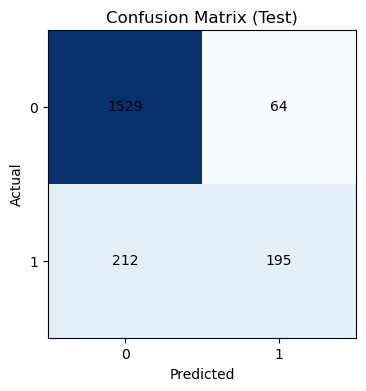

In [10]:
fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix (Test)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center')
plt.show()


## 10. Feature Significance
We use:
- Logistic Regression (absolute coefficient values)
- Random Forest (feature importances)


In [11]:
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_proc, y_train)
coef_abs = np.abs(log_reg.coef_[0])
top_k = 15
idx_lr = np.argsort(coef_abs)[::-1][:top_k]
pd.DataFrame({
    "Feature": [feature_names[i] for i in idx_lr],
    "Abs_Coefficient": coef_abs[idx_lr]
})


,Feature,Abs_Coefficient
0,Geography_Germany,0.819952
1,Age,0.738520
2,Gender_Male,0.522198
3,IsActiveMember,0.515739
4,Balance,0.161558
5,CreditScore,0.085954
6,NumOfProducts,0.070655
7,EstimatedSalary,0.047797
8,Geography_Spain,0.043700
9,HasCrCard,0.032120


In [12]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X_train_proc, y_train)
imp = rf.feature_importances_
idx_rf = np.argsort(imp)[::-1][:top_k]
pd.DataFrame({
    "Feature": [feature_names[i] for i in idx_rf],
    "RF_Importance": imp[idx_rf]
})


,Feature,RF_Importance
0,Age,0.238153
1,EstimatedSalary,0.146135
2,CreditScore,0.143626
3,Balance,0.143112
4,NumOfProducts,0.128751
5,Tenure,0.080574
6,IsActiveMember,0.040130
7,Geography_Germany,0.028509
8,HasCrCard,0.019003
9,Gender_Male,0.017874


## Wrap-Up Summary

In this assignment, we designed and implemented a **three-layer Artificial Neural Network (ANN)** to predict customer churn using the `Churn_Modelling.csv` dataset (10,000 records, 14 columns). The target variable `Exited` is imbalanced, with **79.6% non-churn** and **20.4% churn**.

**Model architecture:**
- **Dense(64, ReLU)** → **Dense(32, ReLU)** → **Dense(1, Sigmoid)**
- **Optimizer:** Adam  
- **Loss:** Binary Crossentropy  
- **Data split:** 80% train / 20% test (stratified by churn)

**Preprocessing:**
- One-Hot Encoding for categorical variables (`Geography`, `Gender`) with `drop='first'`
- Standard Scaling for all numeric variables
- Final engineered feature count: **10**

**Test Set Performance:**
- **Accuracy:** 0.862  
- **Precision (churn):** 0.753  
- **Recall (churn):** 0.479  
- **F1-score (churn):** 0.586  
- **Confusion Matrix:** TN=1529, FP=64, FN=212, TP=195

The model performs strongly in identifying non-churn customers (96% recall for class 0) while achieving reasonable precision for churn prediction. However, recall for churn cases is moderate, indicating that some churners are still being missed.

**Feature importance analysis** (auxiliary models) highlights:
- **Random Forest Top Predictors:** Age, EstimatedSalary, CreditScore, Balance, NumOfProducts
- **Logistic Regression Top Predictors (magnitude):** Geography_Germany, Age, Gender_Male, IsActiveMember, Balance

**Key insights:**
- **Age** and **geographic region** show strong influence on churn likelihood.
- **Balance** and **product usage** patterns are also significant.
- Class imbalance may contribute to lower recall for churners; future work could apply class weighting, oversampling, or threshold tuning.

**Conclusion:**  
The preprocessing pipeline and ANN architecture met the project requirements and achieved **86.2% accuracy** on the test set. This demonstrates the potential of ANN models for churn prediction in banking, though targeted improvements could enhance recall for minority churn cases.
